<a href="https://colab.research.google.com/github/LamaAlghailan/multi-model-agentic-support/blob/main/01_Model_A_Intent_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model A — Intent Classifier
### Tuwaiq Weekend Project: Multi-Model Agentic Technical Support System

**Goal:** Fine-tune `distilbert-base-uncased` for **Sequence Classification** over 8 technical-support intents.

We will:
1. Build a balanced dataset with at least 12 examples per intent.
2. Create stratified train/validation/test splits.
3. Measure a baseline **before fine-tuning**.
4. Tokenize the text.
5. Fine-tune DistilBERT.
6. Evaluate Accuracy, Macro Precision, Macro Recall, Macro F1.
7. Inspect the confusion matrix and per-class recall.
8. Check the project quality gate.
9. Save the model and tokenizer.
10. Run inference with confidence scores.
11. Sweep confidence thresholds for routing.

> Important: Do not fabricate metrics. Run the notebook and report the values you actually obtain.

## 0. Install dependencies

This notebook is designed for Google Colab.

- `transformers`: pretrained model + Trainer
- `datasets`: Hugging Face Dataset
- `accelerate`: backend used by Trainer
- `scikit-learn`: splitting and metrics
- `matplotlib`: confusion matrix

In [2]:
!pip -q install -U transformers datasets accelerate scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 58.2 MB/s eta 0:00:00


## 1. Imports and reproducibility

A fixed random seed makes the split and training setup more reproducible.

In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainingArguments,
    Trainer,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 2. Define the intent taxonomy

The project brief suggests 8 intents:

- `authentication`
- `network`
- `deployment`
- `database`
- `gpu`
- `api`
- `package`
- `general`

A good intent taxonomy should be **separable** and **actionable**:
- separable: examples should not overlap heavily
- actionable: the class should help the router decide what to do next

In [4]:
LABELS = [
    "authentication",
    "network",
    "deployment",
    "database",
    "gpu",
    "api",
    "package",
    "general",
]

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

label2id

{'authentication': 0,
 'network': 1,
 'deployment': 2,
 'database': 3,
 'gpu': 4,
 'api': 5,
 'package': 6,
 'general': 7}

## 3. Build a stronger balanced dataset

The brief requires **at least 12 examples per intent**.  
For a stronger classifier, we use **24 examples per intent**:

- 8 intents
- 24 examples each
- **192 total examples**

The added examples include more realistic overlap and harder wording, not only obvious keyword-based cases.

> Stronger training does not mean only “more epochs”. Better and more varied data is usually the first improvement.

In [5]:
examples = {
    "authentication": [
        "I cannot sign in after resetting MFA.",
        "My password reset worked but login still fails.",
        "The authentication code from my authenticator app is rejected.",
        "I am locked out after too many login attempts.",
        "Single sign-on redirects me back to the login page.",
        "My session expires immediately after I sign in.",
        "The system says my token is invalid even after re-login.",
        "I lost access to my MFA device and cannot authenticate.",
        "The login page keeps saying incorrect credentials.",
        "OAuth login fails with an invalid grant error.",
        "My access token expired and refresh is not working.",
        "The service rejects my API authentication credentials.",
        "The user can reach the application but is repeatedly asked to log in.",
        "SSO succeeds for other users but my account is denied.",
        "The refresh token is present but the session cannot be renewed.",
        "I changed my password and now every device rejects my login.",
        "The API works for public routes but protected routes return unauthorized.",
        "Authentication succeeds locally but fails through the identity provider.",
        "My account is active but the application says access denied.",
        "The bearer token is included but the request is still rejected.",
        "I enrolled a new MFA device but verification codes do not work.",
        "The login callback returns an authentication error after SSO.",
        "Credentials that worked yesterday are suddenly rejected.",
        "I can open the site, but every secured action sends me back to sign in.",
    ],
    "network": [
        "The API times out only from the office VPN.",
        "I can reach the service locally but not over the network.",
        "DNS resolution fails for the internal hostname.",
        "The connection drops whenever I switch to the corporate network.",
        "Requests are blocked by the firewall.",
        "The server is reachable by IP but not by domain name.",
        "The VPN connects but internal services remain unreachable.",
        "I get connection refused when calling the remote host.",
        "Latency becomes very high from another subnet.",
        "The service works on Wi-Fi but not on Ethernet.",
        "The port is open locally but inaccessible from another machine.",
        "Packets are being dropped between the client and server.",
        "The API is healthy on the server but clients from another VLAN cannot reach it.",
        "Curl works inside the container host but fails from my laptop.",
        "The hostname resolves to the wrong address on the office network.",
        "Traffic reaches the load balancer but not the backend service.",
        "The request succeeds on mobile data but fails on the company network.",
        "A proxy is interfering with outbound HTTPS requests.",
        "The service becomes unreachable whenever the VPN tunnel is enabled.",
        "I can ping the machine but TCP connections to the application port fail.",
        "Connections from one subnet work while another subnet always times out.",
        "The client reports a TLS connection timeout before reaching the API.",
        "Internal DNS returns no record for the service name.",
        "Network access stopped after a firewall rule change.",
    ],
    "deployment": [
        "My Docker deployment exits immediately after startup.",
        "The container keeps restarting after deployment.",
        "The application works locally but fails after deployment.",
        "Docker Compose cannot start the support-agent service.",
        "The deployed service returns 503 after the new release.",
        "My image builds successfully but crashes in production.",
        "The container cannot find an environment variable at runtime.",
        "The deployment fails during the image build step.",
        "The service is healthy locally but unhealthy in Docker.",
        "The new release is stuck in a restart loop.",
        "The container starts but the exposed port is not reachable.",
        "Dokploy reports that the application failed to become healthy.",
        "The image was pushed successfully but the new container never becomes ready.",
        "My deployment succeeds, then the service exits a few seconds later.",
        "The Docker health check fails even though the app starts manually.",
        "The production container cannot locate a file that exists on my laptop.",
        "The release failed after changing environment variables in Dokploy.",
        "The container is running but Open WebUI cannot reach the backend service.",
        "A new image version deploys but the old version is still serving traffic.",
        "The service fails only after being packaged into the Docker image.",
        "The Compose stack starts PostgreSQL but the support-agent container crashes.",
        "The application cannot bind to the configured port after deployment.",
        "The build completes but Dokploy marks the release as failed.",
        "After redeployment, the API returns 503 even though it worked before.",
    ],
    "database": [
        "PostgreSQL connections are exhausted.",
        "The database connection pool is at 98 percent.",
        "Queries suddenly became very slow.",
        "The application cannot connect to PostgreSQL.",
        "I get too many connections errors from the database.",
        "A database transaction keeps timing out.",
        "The service reports a deadlock in PostgreSQL.",
        "The database says the relation does not exist.",
        "My SQL query returns duplicate records unexpectedly.",
        "The database migration failed halfway through.",
        "The application loses its database connection under load.",
        "PostgreSQL reports that the connection limit has been reached.",
        "Requests fail whenever the PostgreSQL pool reaches its maximum size.",
        "The API is up but database queries are timing out.",
        "A long-running SQL query is blocking other transactions.",
        "The application reports that the database connection was closed unexpectedly.",
        "PostgreSQL CPU usage is normal but queries are waiting on locks.",
        "The migration created some tables but failed before finishing.",
        "The service starts but cannot authenticate to the database.",
        "Rows are not being committed even though the insert request succeeds.",
        "The connection pool does not release idle PostgreSQL sessions.",
        "A query that used to finish quickly now takes several minutes.",
        "The database is reachable but the selected schema cannot be found.",
        "The API returns errors because all available database connections are busy.",
    ],
    "gpu": [
        "CUDA is available but training stays on CPU.",
        "PyTorch cannot detect my GPU.",
        "Training crashes with CUDA out of memory.",
        "The GPU utilization stays at zero during training.",
        "Torch says CUDA is not available.",
        "My model does not move to the GPU.",
        "The CUDA driver version is incompatible with PyTorch.",
        "Training is extremely slow even though a GPU is attached.",
        "I get a device mismatch between CPU and CUDA tensors.",
        "The GPU memory remains allocated after the training cell stops.",
        "Mixed precision training fails on my GPU.",
        "The notebook runtime has a GPU but Transformers is using CPU.",
        "nvidia-smi shows the GPU but torch.cuda.is_available returns false.",
        "The model is on CUDA but one input tensor is still on CPU.",
        "Training stops because there is not enough VRAM for the batch.",
        "The GPU is visible but utilization remains near zero during each epoch.",
        "My CUDA toolkit and installed PyTorch build do not match.",
        "Moving the model to cuda causes an out of memory exception.",
        "The runtime reports a GPU, but the Trainer selects the CPU device.",
        "I reduced the batch size but CUDA memory is still exhausted.",
        "The model loads on GPU but generation fails with a device error.",
        "GPU memory keeps increasing between training runs.",
        "bf16 is not supported on the selected GPU.",
        "Training became much slower after the process stopped using CUDA.",
    ],
    "api": [
        "The endpoint returns HTTP 422.",
        "My POST request returns a 500 error.",
        "The API responds with 401 Unauthorized.",
        "FastAPI rejects my request body as invalid.",
        "The endpoint returns 404 even though the route exists.",
        "The API returns 503 after deployment.",
        "My JSON payload does not match the request schema.",
        "The REST endpoint hangs without returning a response.",
        "The server returns method not allowed for my request.",
        "The API response is missing an expected field.",
        "FastAPI validation fails for one of the parameters.",
        "The client receives an internal server error from the endpoint.",
        "The request reaches FastAPI but Pydantic rejects one field.",
        "The endpoint accepts GET but rejects my POST request.",
        "The API returns a validation error for a required property.",
        "The response status is 200 but the JSON schema is wrong.",
        "The route works in Swagger but my client receives 422.",
        "The endpoint returns unauthorized even though the service itself is healthy.",
        "The API stops responding when I send a large request body.",
        "My request URL is correct but FastAPI says the route was not found.",
        "The server sends 500 whenever this endpoint is called.",
        "The JSON response cannot be parsed by the client.",
        "A required query parameter is missing from the API call.",
        "The chat completions endpoint rejects the request format.",
    ],
    "package": [
        "Which version of transformers supports this feature?",
        "Pip cannot resolve the package dependencies.",
        "I get a version conflict between torch and transformers.",
        "The package import fails after upgrading Python.",
        "Which accelerate version is compatible with this setup?",
        "Bitsandbytes fails to install in my environment.",
        "A library function disappeared after a package update.",
        "Pip says no matching distribution was found.",
        "The installed package version is different from the required one.",
        "PEFT and Transformers have incompatible versions.",
        "The dependency resolver reports conflicting requirements.",
        "Which version of LangGraph should I install?",
        "Installing TRL upgraded transformers and now my code no longer works.",
        "The import error started after I changed the PEFT version.",
        "Which bitsandbytes release supports this CUDA environment?",
        "Pip installs the package but Python still imports an older version.",
        "The requirements file contains incompatible dependency constraints.",
        "A method used in the notebook is missing from my installed transformers version.",
        "Accelerate needs a newer version than the one currently installed.",
        "The package installs on Linux but fails on my current Python version.",
        "I need to know which torch build matches this CUDA version.",
        "Updating one dependency breaks another library in the environment.",
        "The environment contains two conflicting versions of the same library.",
        "Which version of TRL works with my current PEFT installation?",
    ],
    "general": [
        "Explain what LoRA is.",
        "What is the difference between training and inference?",
        "What does fine-tuning mean?",
        "Explain QLoRA in simple terms.",
        "What is a tokenizer?",
        "Why do language models use attention?",
        "What is an embedding?",
        "Explain what a context window is.",
        "What is supervised fine-tuning?",
        "What is the difference between precision and recall?",
        "What does quantization do to a model?",
        "What is an agent in an AI system?",
        "Why do we split data into train validation and test sets?",
        "What is the purpose of a confidence threshold?",
        "Explain the difference between an encoder and a decoder model.",
        "What does a classification head do?",
        "Why do we use softmax after logits?",
        "What is cross entropy loss?",
        "What is overfitting?",
        "Why is macro F1 useful for classification?",
        "What does a router do in a multi-model system?",
        "What is dynamic padding?",
        "What is the difference between LoRA and full fine-tuning?",
        "Why do we need a Golden Set before deployment?",
    ],
}

rows = []
for label, texts in examples.items():
    assert len(texts) == 24, f"{label} has {len(texts)} examples, expected 24"
    for text in texts:
        rows.append({
            "text": text,
            "intent": label,
            "label": label2id[label],
        })

df = pd.DataFrame(rows)

print("Total examples:", len(df))
print(df["intent"].value_counts().sort_index())
df.sample(8, random_state=SEED)

Total examples: 192
intent
api               24
authentication    24
database          24
deployment        24
general           24
gpu               24
network           24
package           24
Name: count, dtype: int64


,text,intent,label
45,The client reports a TLS connection timeout be...,network,1
136,The route works in Swagger but my client recei...,api,5
76,I get too many connections errors from the dat...,database,3
143,The chat completions endpoint rejects the requ...,api,5
113,Moving the model to cuda causes an out of memo...,gpu,4
177,What is the difference between precision and r...,general,7
15,I changed my password and now every device rej...,authentication,0
18,My account is active but the application says ...,authentication,0


## 4. Sanity checks before splitting

Before training, verify:
- no missing text
- no duplicated text
- all labels are expected
- dataset is balanced

In [6]:
assert df["text"].notna().all()
assert df["intent"].isin(LABELS).all()
assert df["text"].duplicated().sum() == 0

print("Duplicates:", df["text"].duplicated().sum())
print("\nClass distribution:")
print(df["intent"].value_counts())

Duplicates: 0

Class distribution:
intent
authentication    24
network           24
deployment        24
database          24
gpu               24
api               24
package           24
general           24
Name: count, dtype: int64


## 5. Stratified train / validation / test split

With 24 examples per class, we use:

- **Train:** 18 examples per class → 144 total
- **Validation:** 3 examples per class → 24 total
- **Test:** 3 examples per class → 24 total

This gives the model more training data while keeping separate validation and test sets.

`stratify=` preserves the class distribution.

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=48,           # 6 examples per class held out
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=24,           # 3 examples per class for test
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["intent"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["intent"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["intent"].value_counts().sort_index())

Train: 144
Validation: 24
Test: 24

Train distribution:
intent
api               18
authentication    18
database          18
deployment        18
general           18
gpu               18
network           18
package           18
Name: count, dtype: int64

Validation distribution:
intent
api               3
authentication    3
database          3
deployment        3
general           3
gpu               3
network           3
package           3
Name: count, dtype: int64

Test distribution:
intent
api               3
authentication    3
database          3
deployment        3
general           3
gpu               3
network           3
package           3
Name: count, dtype: int64


## 6. Convert pandas DataFrames to Hugging Face Datasets

`Trainer` works naturally with Hugging Face `Dataset` objects.

In [8]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

train_ds

Dataset({
    features: ['text', 'intent', 'label'],
    num_rows: 144
})

## 7. Load tokenizer and pretrained base model

We use `distilbert-base-uncased`.

Important:
- DistilBERT already has pretrained language representations.
- The **classification head** is newly initialized for our 8 classes.
- Before fine-tuning, that head has not learned our intent taxonomy yet.

This is why the pre-fine-tuning result is our baseline.

In [23]:
MODEL_A = "distilbert-base-uncased"

tokenizer_a = AutoTokenizer.from_pretrained(MODEL_A)

model_a = AutoModelForSequenceClassification.from_pretrained(
    MODEL_A,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
)

print(model_a.config.id2label)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}


## 8. Tokenization + Dynamic Padding

The tokenizer converts raw text into model-readable integers.

We tokenize without padding the whole dataset to 128 tokens. Instead, `DataCollatorWithPadding`
pads each **batch only to the longest sequence in that batch**.

This is called **dynamic padding** and avoids unnecessary computation.

In [24]:
def tokenize_a(batch):
    return tokenizer_a(
        batch["text"],
        truncation=True,
        max_length=128,
    )

train_a = train_ds.map(tokenize_a, batched=True)
val_a = val_ds.map(tokenize_a, batched=True)
test_a = test_ds.map(tokenize_a, batched=True)

# Dynamic padding happens later when Trainer creates each batch.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_a)

sample = train_a[0]
print("Text:", sample["text"])
print("Intent:", sample["intent"])
print("Label ID:", sample["label"])
print("Input IDs:", sample["input_ids"][:20])
print("Tokens:", tokenizer_a.convert_ids_to_tokens(sample["input_ids"][:20]))

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Text: Single sign-on redirects me back to the login page.
Intent: authentication
Label ID: 0
Input IDs: [101, 2309, 3696, 1011, 2006, 2417, 7442, 16649, 2033, 2067, 2000, 1996, 8833, 2378, 3931, 1012, 102]
Tokens: ['[CLS]', 'single', 'sign', '-', 'on', 'red', '##ire', '##cts', 'me', 'back', 'to', 'the', 'log', '##in', 'page', '.', '[SEP]']


## 9. Define classification metrics

We use:
- **Accuracy**
- **Macro Precision**
- **Macro Recall**
- **Macro F1**

Why Macro F1?
Because it computes the metric per class first, then gives every class equal weight.

That prevents a large class from hiding poor performance on a smaller class.

In [11]:
def compute_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    p, r, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": p,
        "recall_macro": r,
        "f1_macro": f1,
    }

## 10. Measure the baseline BEFORE fine-tuning

This is required by the project rubric.

At this point:
- the DistilBERT encoder is pretrained
- the 8-class classification head is newly initialized
- the model has not learned our intent labels

So we evaluate **before calling `.train()`**.

In [25]:
baseline_args = TrainingArguments(
    output_dir="baseline_tmp",
    per_device_eval_batch_size=8,
    report_to="none",
)

baseline_trainer = Trainer(
    model=model_a,
    args=baseline_args,
    eval_dataset=test_a,
    compute_metrics=compute_cls_metrics,
    data_collator=data_collator,
)

baseline_metrics = baseline_trainer.evaluate(test_a)

print("BASELINE METRICS")
for k, v in baseline_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")

Training Loss,Validation Loss,Step,Accuracy,Precision Macro,Recall Macro,F1 Macro
No log,2.081438,0,0.125000,0.033482,0.125000,0.051316


BASELINE METRICS
eval_loss: 2.0814
eval_accuracy: 0.1250
eval_precision_macro: 0.0335
eval_recall_macro: 0.1250
eval_f1_macro: 0.0513


## 11. Stronger fine-tuning configuration

We strengthen the training in a controlled way:

- More data: 24 examples per class
- `5` maximum epochs instead of 3
- `weight_decay=0.01` for regularization
- `warmup_ratio=0.1` for a gentler start
- Linear learning-rate schedule
- Best checkpoint selected by validation Macro F1
- Early stopping if validation Macro F1 stops improving

The purpose is **better generalization**, not simply a lower training loss.

In [26]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

args_a = TrainingArguments(
    output_dir="models/intent_classifier",

    learning_rate=2e-5,
    lr_scheduler_type="linear",
    warmup_steps=18,
    weight_decay=0.01,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=10,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=use_fp16,

    report_to="none",
    seed=SEED,
)
trainer_a = Trainer(
    model=model_a,
    args=args_a,
    train_dataset=train_a,
    eval_dataset=val_a,
    compute_metrics=compute_cls_metrics,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.001,
        )
    ],
)

print("bf16:", use_bf16, "| fp16:", use_fp16)

bf16: True | fp16: False


## 12. Train the model

During fine-tuning:
1. text becomes tokens
2. DistilBERT produces contextual representations
3. the classification head produces 8 logits
4. Cross-Entropy Loss compares logits with the true label
5. backpropagation computes gradients
6. the optimizer updates model parameters

In [27]:
train_result = trainer_a.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.076148,2.053493,0.166667,0.150000,0.166667,0.104167
2,2.012737,1.913707,0.541667,0.429924,0.541667,0.458333
3,1.790353,1.681448,0.750000,0.856250,0.750000,0.734226
4,1.535576,1.451427,0.791667,0.845833,0.791667,0.778869
5,1.284556,1.287277,0.791667,0.822917,0.791667,0.795238
6,1.058459,1.124134,0.875000,0.906250,0.875000,0.878571
7,0.900006,1.009380,0.916667,0.927083,0.916667,0.915476
8,0.788387,0.951989,0.916667,0.927083,0.916667,0.915476
9,0.710657,0.902799,0.916667,0.927083,0.916667,0.915476


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=162, training_loss=1.3507644099953733, metrics={'train_runtime': 127.9826, 'train_samples_per_second': 11.252, 'train_steps_per_second': 1.406, 'total_flos': 5657377166208.0, 'train_loss': 1.3507644099953733, 'epoch': 9.0})

## 13. Final evaluation on the held-out test set

Only after training is complete do we evaluate on `test_a`.

In [28]:
fine_tuned_metrics = trainer_a.evaluate(test_a)

print("FINE-TUNED TEST METRICS")
for k, v in fine_tuned_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.710657,0.925967,9,0.916667,0.937500,0.916667,0.914286


FINE-TUNED TEST METRICS
eval_loss: 0.9260
eval_accuracy: 0.9167
eval_precision_macro: 0.9375
eval_recall_macro: 0.9167
eval_f1_macro: 0.9143


## 14. Baseline vs fine-tuned comparison

In [29]:
comparison = pd.DataFrame({
    "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    "baseline": [
        baseline_metrics.get("eval_accuracy"),
        baseline_metrics.get("eval_precision_macro"),
        baseline_metrics.get("eval_recall_macro"),
        baseline_metrics.get("eval_f1_macro"),
    ],
    "fine_tuned": [
        fine_tuned_metrics.get("eval_accuracy"),
        fine_tuned_metrics.get("eval_precision_macro"),
        fine_tuned_metrics.get("eval_recall_macro"),
        fine_tuned_metrics.get("eval_f1_macro"),
    ],
})

comparison["improvement"] = comparison["fine_tuned"] - comparison["baseline"]
comparison

,metric,baseline,fine_tuned,improvement
0,accuracy,0.125000,0.916667,0.791667
1,precision_macro,0.033482,0.937500,0.904018
2,recall_macro,0.125000,0.916667,0.791667
3,f1_macro,0.051316,0.914286,0.862970


## 15. Predictions, confusion matrix, and per-class recall

Average metrics are not enough.

The project specifically requires:
- confusion matrix
- per-class recall

This shows **which intents are being confused with which other intents**.

                precision    recall  f1-score   support

authentication       1.00      1.00      1.00         3
       network       0.75      1.00      0.86         3
    deployment       1.00      0.67      0.80         3
      database       0.75      1.00      0.86         3
           gpu       1.00      1.00      1.00         3
           api       1.00      0.67      0.80         3
       package       1.00      1.00      1.00         3
       general       1.00      1.00      1.00         3

      accuracy                           0.92        24
     macro avg       0.94      0.92      0.91        24
  weighted avg       0.94      0.92      0.91        24



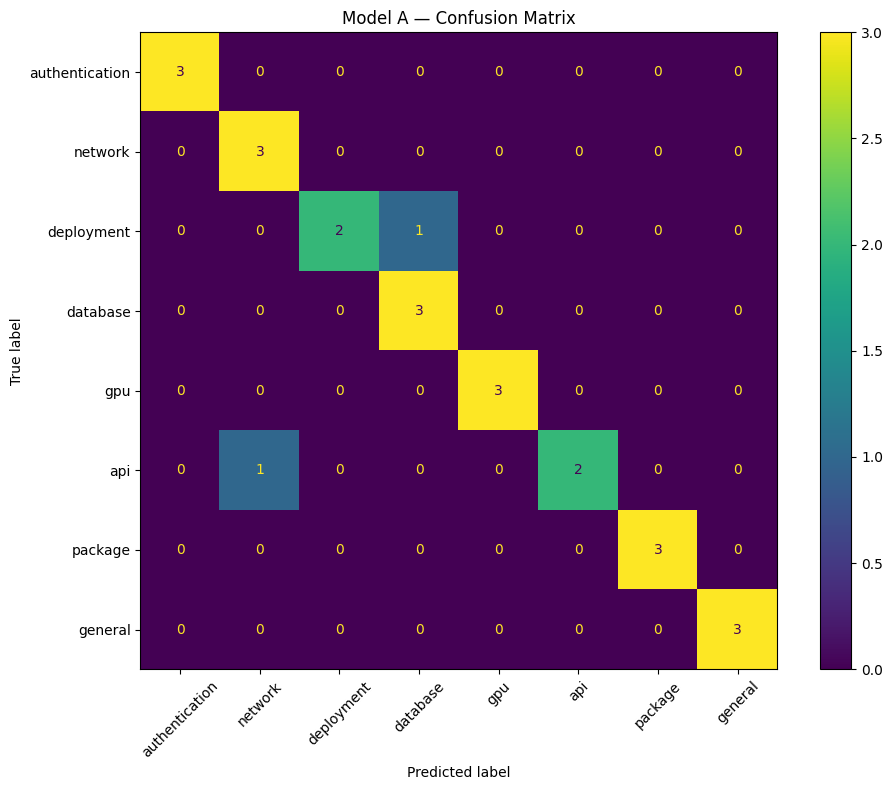

In [30]:
pred_output = trainer_a.predict(test_a)

test_logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(test_logits, axis=-1)

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=list(range(len(LABELS))),
    display_labels=LABELS,
    xticks_rotation=45,
    ax=ax,
)
plt.title("Model A — Confusion Matrix")
plt.tight_layout()
plt.show()

## 15.1 Error analysis

Metrics tell us **how much** the model is wrong.  
Error analysis tells us **where and why** it is wrong.

This table shows only misclassified test examples so we can inspect overlaps such as:
- `api` vs `deployment`
- `authentication` vs `api`
- `database` vs `deployment`

In [31]:
error_rows = []

test_texts = test_df.reset_index(drop=True)["text"].tolist()

for text, true_id, pred_id in zip(test_texts, y_true, y_pred):
    if int(true_id) != int(pred_id):
        error_rows.append({
            "text": text,
            "true_intent": id2label[int(true_id)],
            "predicted_intent": id2label[int(pred_id)],
        })

errors_df = pd.DataFrame(error_rows)

print("Number of misclassified test examples:", len(errors_df))
errors_df

Number of misclassified test examples: 2


,text,true_intent,predicted_intent
0,The client receives an internal server error f...,api,network
1,The Compose stack starts PostgreSQL but the su...,deployment,database


## 16. Quality gate

Recommended gate from the project brief:

- Macro F1 ≥ 0.80
- No class recall < 0.60
- Manually review the confusion matrix

The notebook should report the result honestly. Do not change the numbers to force a pass.

In [32]:
_, per_class_recall, _, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(LABELS))),
    average=None,
    zero_division=0,
)

recall_table = pd.DataFrame({
    "intent": LABELS,
    "recall": per_class_recall,
})

macro_f1 = fine_tuned_metrics["eval_f1_macro"]
min_recall = recall_table["recall"].min()

gate_passed = (macro_f1 >= 0.80) and (min_recall >= 0.60)

print(recall_table)
print()
print(f"Macro F1: {macro_f1:.4f}")
print(f"Minimum class recall: {min_recall:.4f}")
print("QUALITY GATE:", "PASS ✅" if gate_passed else "FAIL ❌")

           intent    recall
0  authentication  1.000000
1         network  1.000000
2      deployment  0.666667
3        database  1.000000
4             gpu  1.000000
5             api  0.666667
6         package  1.000000
7         general  1.000000

Macro F1: 0.9143
Minimum class recall: 0.6667
QUALITY GATE: PASS ✅


## 17. Inspect the model's confidence

`logits` are raw scores.

We apply **Softmax** to convert them into probabilities that sum to 1.

The maximum probability is commonly used as a confidence score for routing.

In [33]:
def predict_intent(text, model=trainer_a.model, tokenizer=tokenizer_a):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits[0]

    probs = torch.softmax(logits, dim=-1)
    pred_id = int(torch.argmax(probs).item())

    return {
        "text": text,
        "intent": id2label[pred_id],
        "confidence": float(probs[pred_id].item()),
        "probabilities": {
            id2label[i]: float(probs[i].item())
            for i in range(len(LABELS))
        },
    }

predict_intent("CUDA is detected, but my training still runs on the CPU.")

{'text': 'CUDA is detected, but my training still runs on the CPU.',
 'intent': 'gpu',
 'confidence': 0.4726066291332245,
 'probabilities': {'authentication': 0.05481438711285591,
  'network': 0.06911804527044296,
  'deployment': 0.10038799792528152,
  'database': 0.09592709690332413,
  'gpu': 0.4726066291332245,
  'api': 0.04367361217737198,
  'package': 0.10869918763637543,
  'general': 0.05477302893996239}}

## 18. Confidence threshold sweep — choose on validation, verify on test

The classifier will later be part of the router:

- confidence ≥ threshold → classifier handles the request
- confidence < threshold → fallback to the LLM router

**Important:** choose/tune the threshold using the validation set, not the test set.

We measure:
- `coverage`: fraction handled directly by classifier
- `accepted_accuracy`: accuracy among accepted high-confidence examples
- `fallback_rate`: fraction sent to the fallback router

In [36]:
# 1) Sweep thresholds on VALIDATION data
val_pred_output = trainer_a.predict(val_a)

val_logits = val_pred_output.predictions
val_true = val_pred_output.label_ids

val_probs = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()
val_confidences = val_probs.max(axis=1)
val_preds = val_probs.argmax(axis=1)

threshold_rows = []

candidate_thresholds = [
    0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70
]

for threshold in candidate_thresholds:
    accepted = val_confidences >= threshold
    coverage = accepted.mean()
    fallback_rate = 1.0 - coverage

    if accepted.sum() > 0:
        accepted_accuracy = accuracy_score(
            val_true[accepted],
            val_preds[accepted]
        )
    else:
        accepted_accuracy = np.nan

    threshold_rows.append({
        "threshold": threshold,
        "coverage": coverage,
        "accepted_accuracy": accepted_accuracy,
        "fallback_rate": fallback_rate,
        "accepted_examples": int(accepted.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)

print("VALIDATION THRESHOLD SWEEP")
display(threshold_df)


# 2) Select threshold using VALIDATION only

MIN_ACCEPTED_ACCURACY = 0.90
MIN_COVERAGE = 0.30

eligible = threshold_df[
    (threshold_df["accepted_accuracy"] >= MIN_ACCEPTED_ACCURACY) &
    (threshold_df["coverage"] >= MIN_COVERAGE) &
    (threshold_df["accepted_examples"] > 0)
].copy()

if len(eligible) > 0:
    eligible = eligible.sort_values(
    ["accepted_accuracy", "coverage"],
    ascending=[False, False],
)

    selected_threshold = float(
        eligible.iloc[0]["threshold"]
    )

else:
    fallback_candidates = threshold_df[
        threshold_df["accepted_examples"] > 0
    ].copy()

    fallback_candidates = fallback_candidates.sort_values(
        ["accepted_accuracy", "coverage"],
        ascending=[False, False],
    )

    selected_threshold = float(
        fallback_candidates.iloc[0]["threshold"]
    )

print("\nSelected threshold from validation:", selected_threshold)


# 3) Verify selected threshold on TEST data

test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_confidences = test_probs.max(axis=1)
test_preds = test_probs.argmax(axis=1)

test_accepted = test_confidences >= selected_threshold

if test_accepted.sum() > 0:
    test_accepted_accuracy = accuracy_score(
        y_true[test_accepted],
        test_preds[test_accepted],
    )
else:
    test_accepted_accuracy = np.nan

print("\nTEST ROUTING BEHAVIOR")
print(f"Coverage: {test_accepted.mean():.3f}")
print(f"Fallback rate: {1 - test_accepted.mean():.3f}")
print(f"Accepted accuracy: {test_accepted_accuracy:.3f}")
print(f"Accepted examples: {int(test_accepted.sum())}/{len(y_true)}")

VALIDATION THRESHOLD SWEEP


,threshold,coverage,accepted_accuracy,fallback_rate,accepted_examples
0,0.20,1.000000,0.916667,0.000000,24
1,0.25,0.916667,0.954545,0.083333,22
2,0.30,0.750000,1.000000,0.250000,18
3,0.35,0.500000,1.000000,0.500000,12
4,0.40,0.375000,1.000000,0.625000,9
5,0.45,0.291667,1.000000,0.708333,7
6,0.50,0.166667,1.000000,0.833333,4
7,0.55,0.125000,1.000000,0.875000,3
8,0.60,0.125000,1.000000,0.875000,3
9,0.65,0.125000,1.000000,0.875000,3



Selected threshold from validation: 0.3

TEST ROUTING BEHAVIOR
Coverage: 0.875
Fallback rate: 0.125
Accepted accuracy: 0.905
Accepted examples: 21/24


## 19. Save the fine-tuned classifier

We save both:
- model weights/config
- tokenizer

Later the router will load this directory directly.

In [37]:
SAVE_DIR = "models/intent_classifier"

trainer_a.save_model(SAVE_DIR)
tokenizer_a.save_pretrained(SAVE_DIR)

print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: models/intent_classifier


In [38]:
!pip install -q huggingface_hub

In [39]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("colab-model-upload")
login(token=hf_token)

In [40]:
repo_id = "Lammem310/multi-model-support-intent-classifier"

trainer_a.model.push_to_hub(repo_id)
tokenizer_a.push_to_hub(repo_id)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uazr0cy/model.safetensors:   0%|          |  575kB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Lammem310/multi-model-support-intent-classifier/commit/cc98cf065bb45afc4f5fe1f56e4823015be760ec', commit_message='Upload tokenizer', commit_description='', oid='cc98cf065bb45afc4f5fe1f56e4823015be760ec', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Lammem310/multi-model-support-intent-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='Lammem310/multi-model-support-intent-classifier'), pr_revision=None, pr_num=None)

In [41]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

repo_id = "Lammem310/multi-model-support-intent-classifier"

hf_tokenizer = AutoTokenizer.from_pretrained(repo_id)

hf_model = AutoModelForSequenceClassification.from_pretrained(repo_id)

print("Loaded from Hugging Face successfully ✅")
print(hf_model.config.id2label)

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded from Hugging Face successfully ✅
{0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}


In [42]:
import torch

text = "My PostgreSQL connections are exhausted."

inputs = hf_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

with torch.no_grad():
    logits = hf_model(**inputs).logits[0]

probs = torch.softmax(logits, dim=-1)

pred_id = int(torch.argmax(probs))

print("Intent:", hf_model.config.id2label[pred_id])
print("Confidence:", float(probs[pred_id]))

Intent: database
Confidence: 0.5007282495498657


## 20. Reload test

Always verify that the saved artifact can be loaded independently.

In [43]:
reloaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
reloaded_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)

print("Reloaded labels:", reloaded_model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Reloaded labels: {0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}


## 21. Example router-facing function

This is close to the function that will later live in `src/routers.py`.

In [44]:
@torch.no_grad()
def classifier_route(text: str, threshold: float = selected_threshold):
    inputs = reloaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    )

    logits = reloaded_model(**inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)

    idx = int(torch.argmax(probs))
    confidence = float(probs[idx])

    return {
        "intent": reloaded_model.config.id2label[idx],
        "confidence": confidence,
        "source": "classifier",
        "needs_fallback": confidence < threshold,
        "threshold": threshold,
    }

classifier_route("My PostgreSQL connections are exhausted.")

{'intent': 'database',
 'confidence': 0.5007282495498657,
 'source': 'classifier',
 'needs_fallback': False,
 'threshold': 0.3}

## 22. Training logs

Keep the real logs for your final report.

In [45]:
history_df = pd.DataFrame(trainer_a.state.log_history)
history_df

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.076148,2.744416,0.000019,1.0,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,18,2.053493,0.166667,0.150000,0.166667,0.104167,0.0509,471.968,58.996,NaN,NaN,NaN,NaN,NaN
2,2.012737,3.717715,0.000018,2.0,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,36,1.913707,0.541667,0.429924,0.541667,0.458333,0.0329,730.498,91.312,NaN,NaN,NaN,NaN,NaN
4,1.790353,5.207646,0.000016,3.0,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,54,1.681448,0.750000,0.856250,0.750000,0.734226,0.0299,803.154,100.394,NaN,NaN,NaN,NaN,NaN
6,1.535576,4.801795,0.000013,4.0,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,72,1.451427,0.791667,0.845833,0.791667,0.778869,0.0301,798.073,99.759,NaN,NaN,NaN,NaN,NaN
8,1.284556,4.298616,0.000011,5.0,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,90,1.287277,0.791667,0.822917,0.791667,0.795238,0.0418,574.543,71.818,NaN,NaN,NaN,NaN,NaN


## 22.1 Inspect learning curves

We inspect the real Trainer logs to look for signs of overfitting.

Typical warning sign:
- training loss keeps decreasing
- validation loss starts increasing

That means the model is memorizing training examples instead of generalizing.

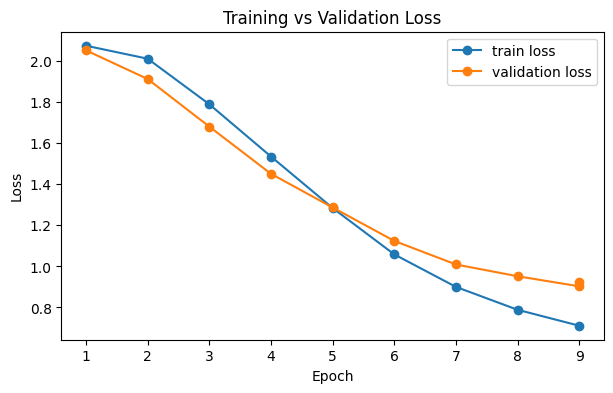

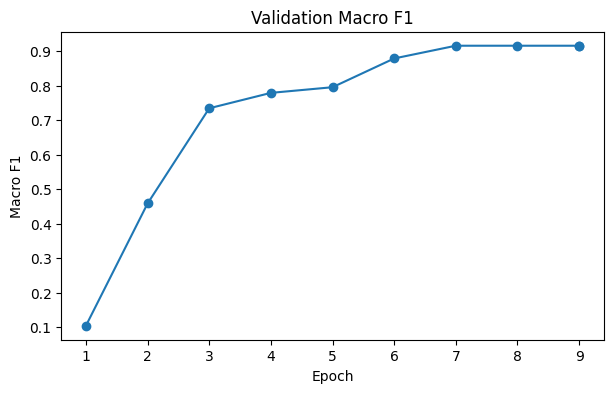

In [46]:
history_df = pd.DataFrame(trainer_a.state.log_history)

train_curve = history_df.dropna(subset=["loss"]) if "loss" in history_df.columns else pd.DataFrame()
eval_curve = history_df.dropna(subset=["eval_loss"]) if "eval_loss" in history_df.columns else pd.DataFrame()

if not train_curve.empty:
    plt.figure(figsize=(7, 4))
    plt.plot(train_curve["epoch"], train_curve["loss"], marker="o", label="train loss")
    if not eval_curve.empty:
        plt.plot(eval_curve["epoch"], eval_curve["eval_loss"], marker="o", label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

if not eval_curve.empty and "eval_f1_macro" in eval_curve.columns:
    plt.figure(figsize=(7, 4))
    plt.plot(eval_curve["epoch"], eval_curve["eval_f1_macro"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Validation Macro F1")
    plt.show()

## 23. Final Model A checklist

Before moving to Model B, confirm:

- [ ] Dataset has **24 examples per intent** (192 total)
- [ ] Intent classes are justified and reasonably separable
- [ ] Train/validation/test splits are stratified
- [ ] Baseline was measured before fine-tuning
- [ ] Dynamic padding is used correctly
- [ ] Accuracy + Macro Precision/Recall/F1 are recorded
- [ ] Confusion matrix was inspected
- [ ] Misclassified examples were reviewed
- [ ] Per-class recall was checked
- [ ] Quality gate result is documented honestly
- [ ] Confidence threshold was chosen from **validation data**
- [ ] Test routing behavior was reported only after choosing the threshold
- [ ] Training/validation curves were inspected for overfitting
- [ ] Model and tokenizer were saved and reloaded successfully

### Mental model

**Inference**

`text → tokenizer → DistilBERT encoder → classification head → logits → softmax → intent + confidence`

**Training**

`text → tokenizer → model → logits + true label → cross-entropy loss → backpropagation → optimizer update`

**Production routing**

`intent + confidence → high confidence: use classifier | low confidence: LLM-router fallback`

## Hugging Face Upload & Verification

This section uses one consistent `repo_id` for upload and reload, and explicitly uses the Colab secret token.


In [47]:
from google.colab import userdata
from huggingface_hub import login, HfApi
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Read the token securely from Colab Secrets
hf_token = userdata.get("colab-model-upload")
login(token=hf_token)

# IMPORTANT: use the exact same repo_id for upload and reload
repo_id = "Lammem310/multi-model-support-intent-classifier"

# Confirm the authenticated Hugging Face account
api = HfApi(token=hf_token)
print("Logged in as:", api.whoami()["name"])
print("Using repo:", repo_id)

# Upload the trained model and tokenizer
trainer_a.model.push_to_hub(repo_id, token=hf_token)
tokenizer_a.push_to_hub(repo_id, token=hf_token)

# Reload directly from Hugging Face Hub to verify the artifact
hf_tokenizer = AutoTokenizer.from_pretrained(repo_id, token=hf_token)
hf_model = AutoModelForSequenceClassification.from_pretrained(repo_id, token=hf_token)

print("Loaded from Hugging Face successfully ✅")
print("Labels:", hf_model.config.id2label)


Logged in as: Lammem310
Using repo: Lammem310/multi-model-support-intent-classifier


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...1ulimke/model.safetensors:   3%|2         | 7.99MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded from Hugging Face successfully ✅
Labels: {0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}


In [51]:
predict_intent(
    "CUDA is detected, but my training still runs on the CPU.",
    model=hf_model,
    tokenizer=hf_tokenizer,
)

{'text': 'CUDA is detected, but my training still runs on the CPU.',
 'intent': 'gpu',
 'confidence': 0.4726066291332245,
 'probabilities': {'authentication': 0.05481438711285591,
  'network': 0.06911807507276535,
  'deployment': 0.10038800537586212,
  'database': 0.09592711180448532,
  'gpu': 0.4726066291332245,
  'api': 0.04367361217737198,
  'package': 0.10869914293289185,
  'general': 0.05477301403880119}}

In [52]:
import torch

text = "My PostgreSQL connections are exhausted."

inputs = hf_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128,
)

with torch.no_grad():
    logits = hf_model(**inputs).logits[0]

probs = torch.softmax(logits, dim=-1)
pred_id = int(torch.argmax(probs))

print("Text:", text)
print("Intent:", hf_model.config.id2label[pred_id])
print("Confidence:", float(probs[pred_id]))


Text: My PostgreSQL connections are exhausted.
Intent: database
Confidence: 0.5007282495498657
